In [6]:
import numpy as np
import matplotlib.pyplot as plt



In [67]:
F = 15 * (2 ** 10) * (2 ** 10) # kbit
u_s = 30 * (2 ** 10) # kbit/s
d_min = 2 * (2 ** 10) # kbit/s
u_node = np.array([300, 700, 2 * (2 ** 10)]) # kbit/s
N = np.array([10, 100, 1000])


In [68]:
F // u_s

512

In [69]:
F // d_min

7680

In [78]:
n = 100

In [96]:
print(n * F / ( u_s + n * u_node[1]))
print(F / u_s)
print(F / d_min)


15616.203335980937
512.0
7680.0


In [70]:
MAX_N = 1000
N = np.linspace(0, MAX_N, MAX_N)



In [71]:
def distribution_time_ClientServer(N, F, u_s, d_min):
    t1 = N * F / u_s
    t2 = F / d_min
    return np.maximum(t1, t2)


In [92]:
def distribution_time_p2p(N, F, u_s, d_min, u_node):
    t1 = F / u_s
    t2 = F / d_min
    t3 = (N * F) / (u_s + u_node * N)
    
    return np.maximum(t1, t2, t3)

In [73]:
y_clientServer = distribution_time_ClientServer(N, F, u_s, d_min)

In [97]:
y_p2p_1 = distribution_time_p2p(N, F, u_s, d_min, u_node[0])
y_p2p_2 = distribution_time_p2p(N, F, u_s, d_min, u_node[1])
y_p2p_3 = distribution_time_p2p(N, F, u_s, d_min, u_node[2])

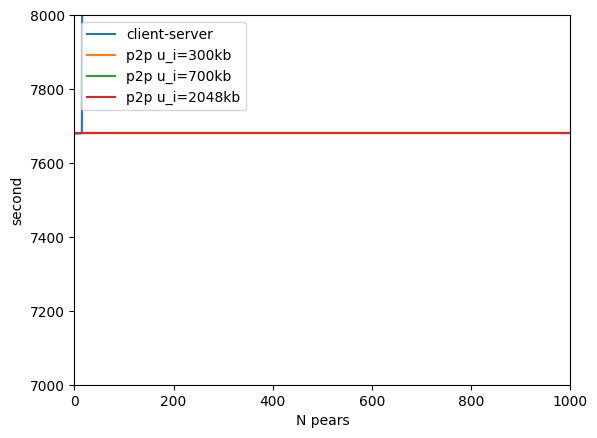

In [99]:
plt.plot(N, y_clientServer, label='client-server')
plt.plot(N, y_p2p_1, label=f'p2p u_i={u_node[0]}kb')
plt.plot(N, y_p2p_2, label=f'p2p u_i={u_node[1]}kb')
plt.plot(N, y_p2p_3, label=f'p2p u_i={u_node[2]}kb')


plt.xlabel("N pears")
plt.ylabel("second")
plt.legend(loc="upper left")

plt.ylim(7000, 8000)
plt.xlim(0, 1000)
plt.show()

In [95]:

a = np.array([1.2, 2.3, 3., 4.6])
b = np.array([10.1, 20.4, 30.1, 40.2])
c = np.array([10.1, 20.4, 30.1, 40.2])
np.maximum(a, b, c)

array([10.1, 20.4, 30.1, 40.2])